# Coursework - Rowan d'Auria (rd761)

### TODO
- Data Exploration

## Q1 - A Mini Normalizing Flow [30 marks]

In this coursework you will implement and train an affine coupling flow (chapter 16 of Prince, *Understanding Deep Learning*) on a 2D dataset.

### (a)

Implement an affine coupling transform for a 2D vector $h = [h_1 \; h_2]^\top$. Implement this in PyTorch. A single coupling layer keeps one component fixed and transforms the other:

$$h_1' = h_1, \qquad h_2' = h_2 \odot \exp[s[h_1]] + t[h_1],$$

where $s[\cdot]$ and $t[\cdot]$ are learned functions, and $\odot$ denotes elementwise multiplication. The $\exp[\cdot]$ is also applied elementwise. In this coursework, implement $s[\cdot]$ and $t[\cdot]$ using a single MLP applied to the masked input, with architecture

$$\text{Linear}(D \to H) \;\to\; \text{ReLU} \;\to\; \text{Linear}(H \to 2D),$$

then split the output into $s[\cdot]$ and $t[\cdot]$. Use at most `hidden=128` and at most `n_layers=8` in your submitted model. For numerical stability you should bound the scale output using $s \leftarrow \tanh[s]$.

Implement both directions:

- the forward map $f[z]$ used for sampling (base $\to$ data), and
- the inverse map $f^{-1}[x]$ used for evaluating $\log p[x]$ (data $\to$ base).

Your code must return both the transformed output and the log-determinant of the Jacobian for that direction.

### (b)

Build a flow by stacking $K$ coupling layers with alternating masks (each dimension should be transformed in some layers). Let the base density be standard normal $p[z] = \mathcal{N}(0, I)$. Implement a function that evaluates $\log p[x]$ for a batch of points.

### (c)

Add two correctness checks and save the results to `results.json`:

- **Invertibility**: for every point in `data/moons_train.csv`, compute $z = f^{-1}[x]$, reconstruct $\hat{x} = f[z]$, and report the maximum absolute reconstruction error over the full training set.
- **Log-det check**: using the first example in `data/moons_train.csv`, numerically estimate the Jacobian of $f^{-1}[\cdot]$ by central differences with step size $\epsilon = 10^{-4}$, and compare $\log|\det J|$ to your analytic log-det. Report the absolute error.

Include both checks as a simple two-panel diagnostic figure saved to `figs/Figure1c.pdf`.

Below we define an `AffineCouplingLayer` that keeps one component fixed and transforms the other via an internal MLP, and a `Flow` that stacks $K$ such layers with alternating masks.

In [3]:
import torch
import torch.nn as nn
import math


class AffineCouplingLayer(nn.Module):
    """Single affine coupling layer for a 2D input h = [h1, h2].

    Forward (base -> data):  h1' = h1,  h2' = h2 * exp(s[h1]) + t[h1]
    Inverse (data -> base):  h1  = h1', h2  = (h2' - t[h1']) * exp(-s[h1'])

    The mask selects which component is fixed (1) vs transformed (0).
    """

    mask: torch.Tensor # needed to avoid type warning

    def __init__(self, dim, hidden, mask):
        super().__init__()
        self.register_buffer("mask", mask)
        # MLP: Linear(D -> H) -> ReLU -> Linear(H -> 2D)
        self.net = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 2 * dim),
        )

    def _st(self, h_masked):
        """Run the MLP and return (t, s) with s bounded by tanh."""
        out = self.net(h_masked)
        t, s = out.chunk(2, dim=-1)
        s = torch.tanh(s)
        return t, s

    def forward(self, h):
        """Forward map f[z] (base -> data).
        Returns (h', log_det_J).
        """
        h_masked = h * self.mask
        t, s = self._st(h_masked)
        # only transform the unmasked components
        h_prime = h_masked + (1 - self.mask) * (h * torch.exp(s) + t)
        # log|det J| = sum of s over transformed (unmasked) dims
        log_det = (s * (1 - self.mask)).sum(dim=-1)
        return h_prime, log_det

    def inverse(self, h_prime):
        """Inverse map f^{-1}[x] (data -> base).
        Returns (h, log_det_J) where log_det_J is for the *inverse* direction.
        """
        h_masked = h_prime * self.mask
        t, s = self._st(h_masked)
        h = h_masked + (1 - self.mask) * ((h_prime - t) * torch.exp(-s))
        # log|det J^{-1}| = -sum of s over transformed dims
        log_det = -(s * (1 - self.mask)).sum(dim=-1)
        return h, log_det


class Flow(nn.Module):
    """Stack of K affine coupling layers with alternating masks.

    Base density: p(z) = N(0, I).
    """

    def __init__(self, dim=2, hidden=128, n_layers=8):
        super().__init__()
        self.dim = dim
        layers = []
        for i in range(n_layers):
            # alternate which component is fixed
            mask = torch.zeros(dim)
            mask[i % 2] = 1.0
            layers.append(AffineCouplingLayer(dim, hidden, mask))
        self.layers = nn.ModuleList(layers)

    def forward(self, z):
        """Forward (sampling) map: z ~ N(0,I) -> x.
        Returns (x, sum of log_det_J).
        """
        log_det_total = torch.zeros(z.shape[0], device=z.device)
        x = z
        for layer in self.layers:
            x, log_det = layer.forward(x)
            log_det_total = log_det_total + log_det
        return x, log_det_total

    def inverse(self, x):
        """Inverse map: x (data) -> z (base).
        Returns (z, sum of log_det_J for the inverse direction).
        """
        log_det_total = torch.zeros(x.shape[0], device=x.device)
        z = x
        for layer in reversed(self.layers):
            z, log_det = layer.inverse(z)
            log_det_total = log_det_total + log_det
        return z, log_det_total

    def log_prob(self, x):
        """Evaluate log p(x) for a batch of data points."""
        z, log_det_inv = self.inverse(x)
        # log p(z) under standard normal
        log_pz = -0.5 * (self.dim * math.log(2 * math.pi) + (z ** 2).sum(dim=-1))
        return log_pz + log_det_inv

### Q1(c) - Correctness Checks

Two checks:

1. **Invertibility**: for every point in `data/moons_train.csv`, compute $z = f^{-1}[x]$, reconstruct $\hat{x} = f[z]$, and report the maximum absolute reconstruction error over the full training set.

2. **Log-det check**: using the first example in `data/moons_train.csv`, numerically estimate the Jacobian of $f^{-1}[\cdot]$ by central differences with step size $\epsilon = 10^{-4}$, and compare $\log|\det J|$ to the analytic log-det. Report the absolute error.

Save a two-panel diagnostic figure to `figs/Figure1c.pdf`.

Invertibility max absolute error: 9.54e-07
Analytic log|det J|:  0.432602
Numerical log|det J|: 0.435983
Log-det absolute error: 3.38e-03


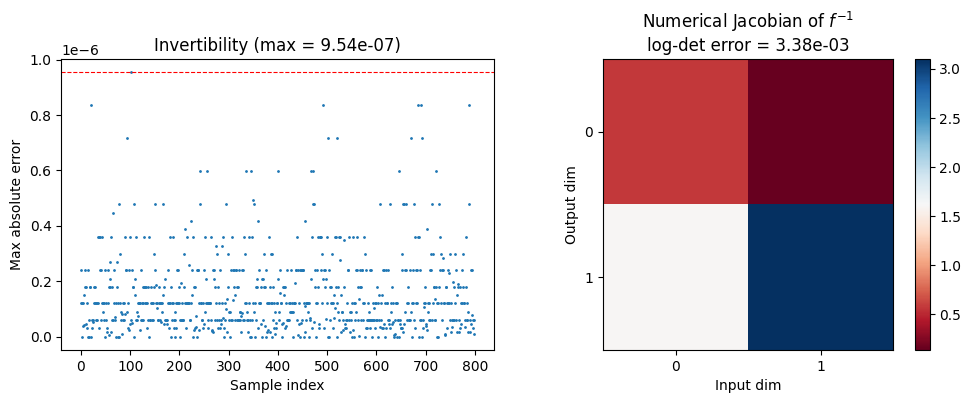

Saved results.json and figs/Figure1c.pdf


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os
import json

# Load training data
train_data = np.loadtxt("data/moons_train.csv", delimiter=",", skiprows=1)
x_train = torch.tensor(train_data[:, :2], dtype=torch.float32)

# Instantiate an untrained flow for the correctness checks
torch.manual_seed(42)
flow = Flow(dim=2, hidden=128, n_layers=8)
flow.eval()

# --- Check 1: Invertibility ---
with torch.no_grad():
    z, _ = flow.inverse(x_train)
    x_hat, _ = flow.forward(z)
    max_abs_error = (x_train - x_hat).abs().max().item()

print(f"Invertibility max absolute error: {max_abs_error:.2e}")

# --- Check 2: Log-det via finite differences ---
eps = 1e-4
x0 = x_train[0:1]  # shape (1, 2)
dim = 2

# Analytic log-det from our inverse
with torch.no_grad():
    _, analytic_log_det = flow.inverse(x0)
    analytic_log_det = analytic_log_det.item()

# Numerical Jacobian by central differences
J = torch.zeros(dim, dim)
for j in range(dim):
    e_j = torch.zeros(1, dim)
    e_j[0, j] = eps
    with torch.no_grad():
        z_plus, _ = flow.inverse(x0 + e_j)
        z_minus, _ = flow.inverse(x0 - e_j)
    J[:, j] = (z_plus - z_minus).squeeze() / (2 * eps)

numerical_log_det = torch.log(torch.abs(torch.det(J))).item()
logdet_abs_error = abs(analytic_log_det - numerical_log_det)

print(f"Analytic log|det J|:  {analytic_log_det:.6f}")
print(f"Numerical log|det J|: {numerical_log_det:.6f}")
print(f"Log-det absolute error: {logdet_abs_error:.2e}")

# --- Figure 1c: two-panel diagnostic ---
os.makedirs("figs", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Panel 1: reconstruction error per sample
with torch.no_grad():
    z_all, _ = flow.inverse(x_train)
    x_hat_all, _ = flow.forward(z_all)
    recon_errors = (x_train - x_hat_all).abs().max(dim=-1).values.numpy()

axes[0].plot(recon_errors, ".", markersize=2)
axes[0].set_xlabel("Sample index")
axes[0].set_ylabel("Max absolute error")
axes[0].set_title(f"Invertibility (max = {max_abs_error:.2e})")
axes[0].axhline(max_abs_error, color="r", linestyle="--", linewidth=0.8)

# Panel 2: Jacobian columns visualised as a heatmap
im = axes[1].imshow(J.numpy(), cmap="RdBu", aspect="equal")
axes[1].set_title(f"Numerical Jacobian of $f^{{-1}}$\nlog-det error = {logdet_abs_error:.2e}")
axes[1].set_xlabel("Input dim")
axes[1].set_ylabel("Output dim")
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
plt.colorbar(im, ax=axes[1])

fig.tight_layout()
fig.savefig("figs/Figure1c.pdf")
plt.show()

# --- Save to results.json ---
results = {
    "correctness": {
        "invertibility_max_abs_error": max_abs_error,
        "logdet_finite_diff_abs_error": logdet_abs_error,
    }
}

with open("results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved results.json and figs/Figure1c.pdf")

## Q2 - Training Pipeline [30 marks]

### (a) Tiny subset training

Use exactly the first 128 rows of `data/moons_train.csv` as the tiny subset. Train the flow on that subset, plot the loss curve, and record the final tiny-set NLL.

Step 500/2000, NLL: 0.0057
Step 1000/2000, NLL: 0.6228
Step 1500/2000, NLL: 0.0940
Step 2000/2000, NLL: -0.0358

Final tiny-set NLL: -0.0399


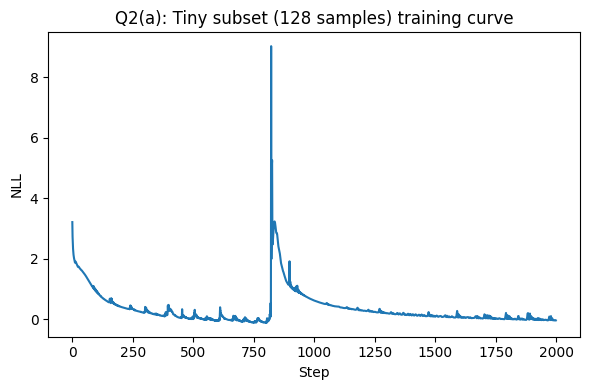

Saved figs/Figure2a.pdf


In [7]:
SEED = 42
N_TINY_STEPS = 2000
LR = 1e-3

x_tiny = x_train[:128]

torch.manual_seed(SEED)
flow_tiny = Flow(dim=2, hidden=128, n_layers=8)
optimizer_tiny = torch.optim.Adam(flow_tiny.parameters(), lr=LR)

tiny_losses = []
for step in range(N_TINY_STEPS):
    loss = -flow_tiny.log_prob(x_tiny).mean()
    optimizer_tiny.zero_grad()
    loss.backward()
    optimizer_tiny.step()
    tiny_losses.append(loss.item())
    if (step + 1) % 500 == 0:
        print(f"Step {step+1}/{N_TINY_STEPS}, NLL: {loss.item():.4f}")

# Final NLL evaluated on the full tiny set
flow_tiny.eval()
with torch.no_grad():
    tinyset_final_nll = -flow_tiny.log_prob(x_tiny).mean().item()
print(f"\nFinal tiny-set NLL: {tinyset_final_nll:.4f}")

# --- Figure 2a ---
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(tiny_losses)
ax.set_xlabel("Step")
ax.set_ylabel("NLL")
ax.set_title("Q2(a): Tiny subset (128 samples) training curve")
fig.tight_layout()
fig.savefig("figs/Figure2a.pdf")
plt.show()
print("Saved figs/Figure2a.pdf")

### (b) + (c) Full training

Train on the full `data/moons_train.csv` with:
- Cosine annealing LR schedule
- Validation loss tracking against `data/moons_val.csv`
- Final checkpoint saved to `checkpoints/flow_full.pt`
- Training log saved to `logs/training_curves.json`

Record final train, validation, and test NLL in `results.json`.

Step 500/5000, Train NLL: 0.2407, Val NLL: 0.3913
Step 1000/5000, Train NLL: 0.1719, Val NLL: 0.4044
Step 1500/5000, Train NLL: 0.1508, Val NLL: 0.4012
Step 2000/5000, Train NLL: 0.1366, Val NLL: 0.4187
Step 2500/5000, Train NLL: 0.1219, Val NLL: 0.4180
Step 3000/5000, Train NLL: 0.1144, Val NLL: 0.4381
Step 3500/5000, Train NLL: 0.0990, Val NLL: 0.4601
Step 4000/5000, Train NLL: 0.0937, Val NLL: 0.4651
Step 4500/5000, Train NLL: 0.0886, Val NLL: 0.4705
Step 5000/5000, Train NLL: 0.0876, Val NLL: 0.4711

Final Train NLL: 0.0876
Final Val NLL:   0.4711
Final Test NLL:  2.4029
Saved checkpoints/flow_full.pt
Saved logs/training_curves.json


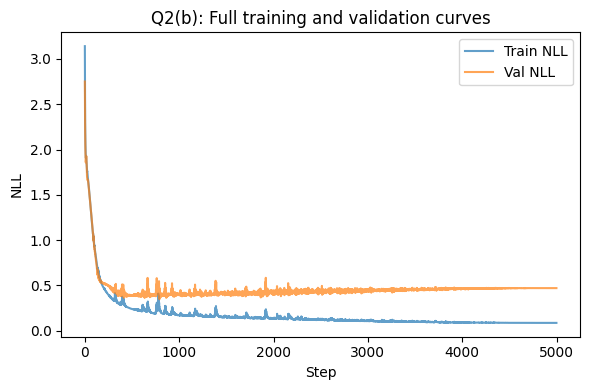

Saved figs/Figure2c.pdf
Updated results.json with training metrics


In [8]:
N_FULL_STEPS = 5000

# Load validation and test data
val_data = np.loadtxt("data/moons_val.csv", delimiter=",", skiprows=1)
test_data = np.loadtxt("data/moons_test.csv", delimiter=",", skiprows=1)
x_val = torch.tensor(val_data[:, :2], dtype=torch.float32)
x_test = torch.tensor(test_data[:, :2], dtype=torch.float32)

# Fresh flow for full training
torch.manual_seed(SEED)
flow_full = Flow(dim=2, hidden=128, n_layers=8)
optimizer_full = torch.optim.Adam(flow_full.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_full, T_max=N_FULL_STEPS)

full_losses = []
full_val_losses = []

for step in range(N_FULL_STEPS):
    flow_full.train()
    loss = -flow_full.log_prob(x_train).mean()
    optimizer_full.zero_grad()
    loss.backward()
    optimizer_full.step()
    scheduler.step()

    full_losses.append(loss.item())

    # Validation loss every step (cheap: only 100 points)
    flow_full.eval()
    with torch.no_grad():
        val_loss = -flow_full.log_prob(x_val).mean().item()
    full_val_losses.append(val_loss)

    if (step + 1) % 500 == 0:
        print(f"Step {step+1}/{N_FULL_STEPS}, Train NLL: {loss.item():.4f}, Val NLL: {val_loss:.4f}")

# --- Final NLLs ---
flow_full.eval()
with torch.no_grad():
    final_train_nll = -flow_full.log_prob(x_train).mean().item()
    final_val_nll = -flow_full.log_prob(x_val).mean().item()
    final_test_nll = -flow_full.log_prob(x_test).mean().item()

print(f"\nFinal Train NLL: {final_train_nll:.4f}")
print(f"Final Val NLL:   {final_val_nll:.4f}")
print(f"Final Test NLL:  {final_test_nll:.4f}")

# --- Save checkpoint ---
os.makedirs("checkpoints", exist_ok=True)
torch.save({
    "state_dict": flow_full.state_dict(),
    "config": {"dim": 2, "hidden": 128, "n_layers": 8},
    "seed": SEED,
}, "checkpoints/flow_full.pt")
print("Saved checkpoints/flow_full.pt")

# --- Save training curves log ---
os.makedirs("logs", exist_ok=True)
with open("logs/training_curves.json", "w") as f:
    json.dump({
        "tiny_loss": tiny_losses,
        "full_loss": full_losses,
        "full_val_loss": full_val_losses,
    }, f)
print("Saved logs/training_curves.json")

# --- Figure 2c ---
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(full_losses, label="Train NLL", alpha=0.7)
ax.plot(full_val_losses, label="Val NLL", alpha=0.7)
ax.set_xlabel("Step")
ax.set_ylabel("NLL")
ax.set_title("Q2(b): Full training and validation curves")
ax.legend()
fig.tight_layout()
fig.savefig("figs/Figure2c.pdf")
plt.show()
print("Saved figs/Figure2c.pdf")

# --- Update results.json ---
with open("results.json", "r") as f:
    results = json.load(f)

results["training"] = {
    "tinyset_final_nll": tinyset_final_nll,
    "final_train_nll": final_train_nll,
    "final_val_nll": final_val_nll,
    "final_test_nll": final_test_nll,
}

with open("results.json", "w") as f:
    json.dump(results, f, indent=2)
print("Updated results.json with training metrics")